In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import ScalarFormatter
import matplotlib.lines as mlines
from matplotlib.ticker import FormatStrFormatter

import seaborn as sns
from pathlib import Path
import re
import json

In [3]:
# read all results.json files from outputs
all_results = list(Path("../outputs").glob("**/results.json"))
datasets_name = ["gigaspeech","spgispeech_2","voxpopuli"]
filtered_results = [result for result in all_results if any(dataset in str(result) for dataset in datasets_name)]
all_train_logs = list(Path("../outputs").glob("**/*.log"))
filtered_train_logs = [log for log in all_train_logs if any(dataset in str(log) for dataset in datasets_name)]


In [ ]:
metadata = {
    "000": {"Lora Rank": 0,"type": "base"},
    "001": {"lora_rank": 0,"type": "standard"},
    "002": {"lora_rank": 8,"type": "lora"},
    "0021": {"lora_rank": 16,"type": "lora"},
    "0022": {"lora_rank": 32,"type": "lora"},
    "0023": {"lora_rank": 64,"type": "lora"},
    "0024": {"lora_rank": 128,"type": "lora"},
    "0025": {"lora_rank": 256,"type": "lora"},
    "0026": {"lora_rank": 512,"type": "lora"},
    "0027": {"lora_rank": 96,"type": "lora"},
}

In [ ]:
# metdadata to dataframe 
df_metadata = pd.DataFrame.from_dict(metadata,orient='index').reset_index()
df_metadata.columns = ['run_name','Lora Rank','type']
gigaspeech_logs = [log for log in all_train_logs if "gigaspeech" in str(log)]
gigaspeech_dict = {}
for log in gigaspeech_logs:
    run_name = str(log).split("/")[3]
    trainable_parameters = 0
    
    with open(log, "r") as f:
        for line in f:
            # Case-insensitive check
            if "trainable params" in line.lower():
                match = re.search(r"trainable params:\s*([\d,]+)", line, re.IGNORECASE)
                if match:
                    # Remove commas and convert to int
                    trainable_parameters = int(match.group(1).replace(",", ""))
                    break
    
    gigaspeech_dict[run_name] = {
        "all_parameters": 816967680, 
        "trainable_parameters": trainable_parameters
    }
df_gigaspeech = pd.DataFrame.from_dict(gigaspeech_dict,orient='index').reset_index()
df_gigaspeech.columns = ['run_name','all_parameters','Trainable Parameters']

df_metadata = pd.merge(df_metadata,df_gigaspeech,on='run_name')
df_metadata['Trainable Parameters (%)'] = df_metadata['Trainable Parameters'].astype(int)/df_metadata['all_parameters'].astype(int)*100
df_metadata

,run_name,Lora Rank,Type,all_parameters,Trainable Parameters,Trainable Parameters (%)
0,000,0,base,816967680,0,0.000000
1,001,0,standard,816967680,53109760,6.500840
2,002,8,lora,816967680,423112,0.051791
3,0021,16,lora,816967680,846224,0.103581
4,0022,32,lora,816967680,1692448,0.207162
5,0023,64,lora,816967680,3384896,0.414324
6,0024,128,lora,816967680,6769792,0.828649
7,0025,256,lora,816967680,13539584,1.657297
8,0026,512,lora,816967680,27079168,3.314595
9,0027,96,lora,816967680,5077344,0.621487


In [127]:
# reading wer from results.json into a results dictionary incuding run_name and wer
gigaspeech_results = [res for res in all_results if "gigaspeech" in str(res)]
results_dict = {}
for res in gigaspeech_results:
    run_name = str(res).split("/")[3]
    with open(res) as f:
        data = json.load(f)
    wer = data['metrics']['wer']
    results_dict[run_name] = {"wer":wer}
df_gigaspeech_results = pd.DataFrame.from_dict(results_dict,orient='index').reset_index()
df_gigaspeech_results.columns = ['run_name','wer']
df_gigaspeech_results['Dataset'] = 'GigaSpeech'
df_gigaspeech_results

,run_name,wer,Dataset
0,0022,0.145282,GigaSpeech
1,0027_r1,0.144148,GigaSpeech
2,0023,0.130334,GigaSpeech
3,0027_r,0.153482,GigaSpeech
4,0021,0.160483,GigaSpeech
5,000,0.149531,GigaSpeech
6,0027_r3,0.142262,GigaSpeech
7,0024,0.133787,GigaSpeech
8,0027_r2,0.140749,GigaSpeech
9,0027,0.148622,GigaSpeech


In [128]:
df_total_gigaspeech = pd.merge(df_metadata,df_gigaspeech_results, on="run_name", how="inner")
df_total_gigaspeech

,run_name,Lora Rank,Type,all_parameters,Trainable Parameters,Trainable Parameters (%),wer,Dataset
0,000,0,base,816967680,0,0.000000,0.149531,GigaSpeech
1,001,0,standard,816967680,53109760,6.500840,0.135231,GigaSpeech
2,002,8,lora,816967680,423112,0.051791,0.166650,GigaSpeech
3,0021,16,lora,816967680,846224,0.103581,0.160483,GigaSpeech
4,0022,32,lora,816967680,1692448,0.207162,0.145282,GigaSpeech
5,0023,64,lora,816967680,3384896,0.414324,0.130334,GigaSpeech
6,0024,128,lora,816967680,6769792,0.828649,0.133787,GigaSpeech
7,0025,256,lora,816967680,13539584,1.657297,0.135291,GigaSpeech
8,0026,512,lora,816967680,27079168,3.314595,0.167381,GigaSpeech
9,0027,96,lora,816967680,5077344,0.621487,0.148622,GigaSpeech


In [129]:
spgispeech_2_results = [res for res in all_results if "spgispeech_2" in str(res)]
results_dict = {}
for res in spgispeech_2_results:
    run_name = str(res).split("/")[3]
    with open(res) as f:
        data = json.load(f)
    wer = data['metrics']['wer']
    results_dict[run_name] = {"wer":wer}
df_spgispeech_results = pd.DataFrame.from_dict(results_dict,orient='index').reset_index()
df_spgispeech_results.columns = ['run_name','wer']
df_spgispeech_results['Dataset'] = 'SPGISpeech_2'
df_total_spgispeech = pd.merge(df_metadata,df_spgispeech_results, on="run_name", how="inner")
df_total_spgispeech

,run_name,Lora Rank,Type,all_parameters,Trainable Parameters,Trainable Parameters (%),wer,Dataset
0,000,0,base,816967680,0,0.000000,0.115615,SPGISpeech_2
1,001,0,standard,816967680,53109760,6.500840,0.068312,SPGISpeech_2
2,002,8,lora,816967680,423112,0.051791,0.079877,SPGISpeech_2
3,0021,16,lora,816967680,846224,0.103581,0.075773,SPGISpeech_2
4,0022,32,lora,816967680,1692448,0.207162,0.071233,SPGISpeech_2
5,0023,64,lora,816967680,3384896,0.414324,0.068598,SPGISpeech_2
6,0024,128,lora,816967680,6769792,0.828649,0.071936,SPGISpeech_2
7,0026,512,lora,816967680,27079168,3.314595,0.076543,SPGISpeech_2
8,0027,96,lora,816967680,5077344,0.621487,0.069845,SPGISpeech_2


In [130]:
df_total = pd.concat([df_total_gigaspeech, df_total_spgispeech],ignore_index=True)
df_total['WER (%)'] = df_total['wer']*100
df_total

,run_name,Lora Rank,Type,all_parameters,Trainable Parameters,Trainable Parameters (%),wer,Dataset,WER (%)
0,000,0,base,816967680,0,0.000000,0.149531,GigaSpeech,14.953090
1,001,0,standard,816967680,53109760,6.500840,0.135231,GigaSpeech,13.523135
2,002,8,lora,816967680,423112,0.051791,0.166650,GigaSpeech,16.664974
3,0021,16,lora,816967680,846224,0.103581,0.160483,GigaSpeech,16.048349
4,0022,32,lora,816967680,1692448,0.207162,0.145282,GigaSpeech,14.528216
5,0023,64,lora,816967680,3384896,0.414324,0.130334,GigaSpeech,13.033353
6,0024,128,lora,816967680,6769792,0.828649,0.133787,GigaSpeech,13.378703
7,0025,256,lora,816967680,13539584,1.657297,0.135291,GigaSpeech,13.529081
8,0026,512,lora,816967680,27079168,3.314595,0.167381,GigaSpeech,16.738057
9,0027,96,lora,816967680,5077344,0.621487,0.148622,GigaSpeech,14.862170


In [ ]:
def plot_results(df, ax=None, title="WER (%) vs LoRA Rank", add_legend=True):
    if ax is None:
        fig, ax = plt.subplots(figsize=(10, 6))
    x_col_name = 'Lora Rank' 
    label_col_name = 'Trainable Parameters (%)'
    line_data = df[df[x_col_name] > 0].sort_values(by=x_col_name)
    baseline_data = df[df[x_col_name] == 0]
    # 1. Plot Line
    line_handle, = ax.plot(
        line_data[x_col_name], 
        line_data['WER (%)'], 
        linestyle='-', 
        alpha=0.7, 
        color='tab:blue',
        label='LoRA Model'
    )
    # 2. Scatter Points
    scale_factor = 300
    ax.scatter(
        line_data[x_col_name], 
        line_data['WER (%)'], 
        s=line_data[label_col_name] * scale_factor, 
        color='tab:blue',
        alpha=1.0,
        zorder=5
    )
    # 3. Baselines
    baseline_handles = []
    colors = ['red', 'green', 'orange', 'purple']
    for i, (idx, row) in enumerate(baseline_data.iterrows()):
        label_text = f"{row['type']}" # Simplified label for shared legend
        h = ax.axhline(
            y=row['WER (%)'], 
            color=colors[i % len(colors)], 
            linestyle='--', 
            label=label_text
        )
        baseline_handles.append(h)
    # --- AXES SETTINGS ---
    ax.set_xscale('log') 
    ax.set_xlabel('LoRA Rank (r)') 
    ax.set_ylabel('WER (%)')
    ax.set_title(title)
    ax.grid(True, which="both", linestyle='--', alpha=0.5)
    
    ax.set_xticks(sorted(line_data[x_col_name].unique()))
    ax.get_xaxis().set_major_formatter(ScalarFormatter())
    # --- HANDLE COLLECTION ---
    size_description_handle = mlines.Line2D(
        [], [], 
        color='tab:blue', 
        marker='o', 
        linestyle='None',
        markersize=10, 
        label='∝ #Trainable Params'
    )
    all_handles = [line_handle] + baseline_handles + [size_description_handle]
    all_labels = [h.get_label() for h in all_handles]
    if add_legend:
        ax.legend(all_handles, all_labels, loc='best')
    return all_handles, all_labels

In [132]:
df_g = df_total[df_total['Dataset'] == "GigaSpeech"]
df_s = df_total[df_total['Dataset'] == "SPGISpeech_2"]

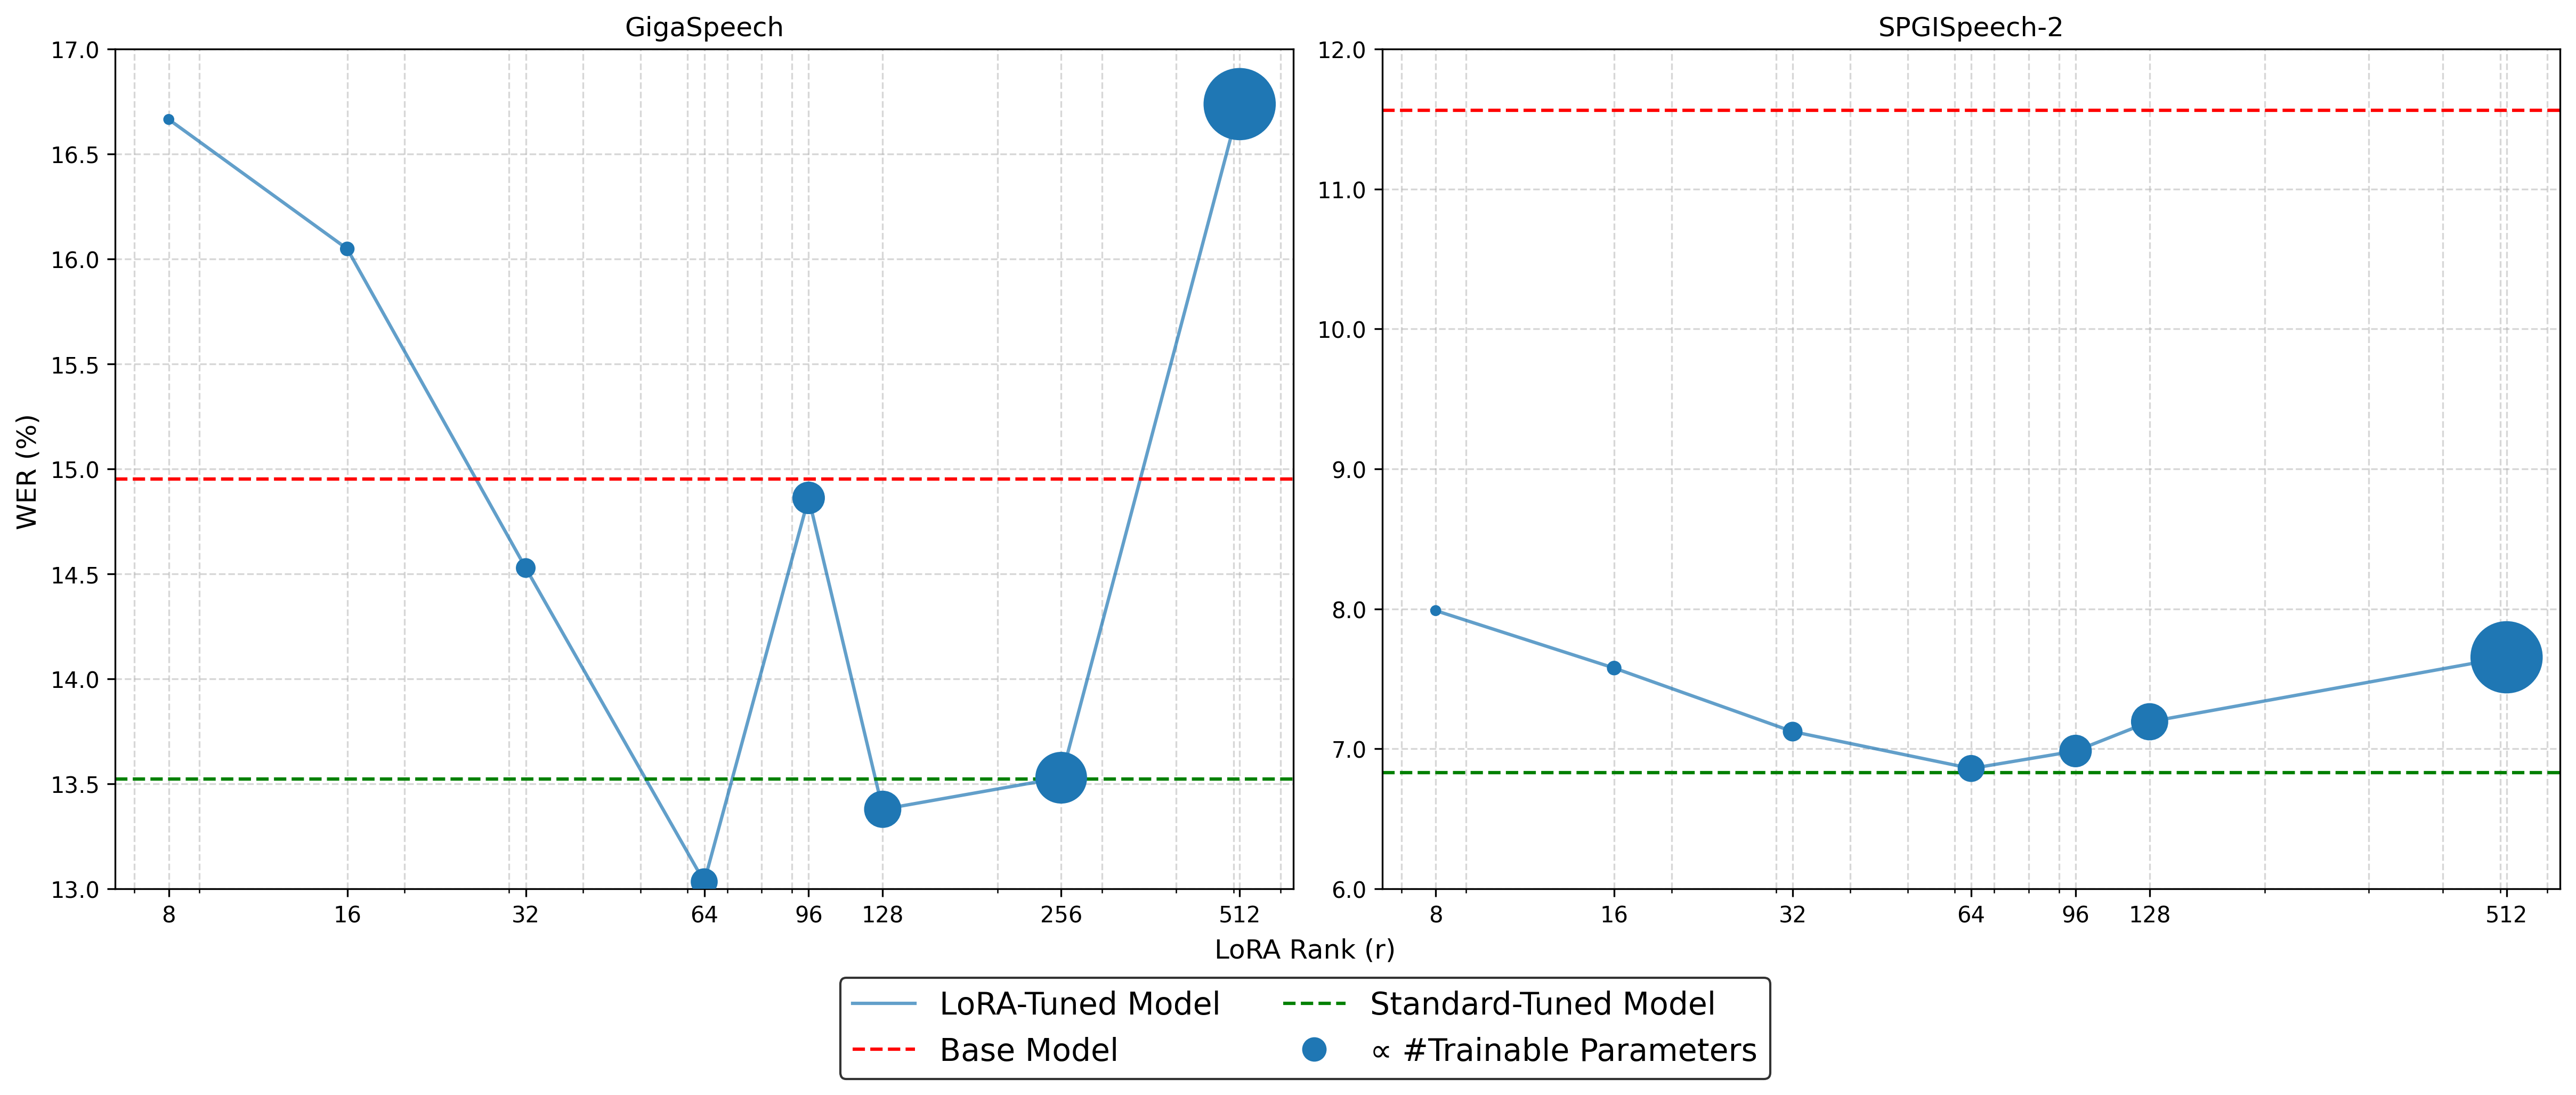

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6),dpi=300)
# 1. Plot first dataset (don't add local legend, but capture the handles)
handles, labels = plot_results(df_g, ax=axes[0], title="GigaSpeech", add_legend=False)
labels = ['LoRA-Tuned Model', 'Base Model', 'Standard-Tuned Model', '∝ #Trainable Parameters']
# 2. Plot second dataset (don't add local legend)
# We assume the legend entries (colors/types) are similar enough to share
plot_results(df_s, ax=axes[1], title="SPGISpeech-2", add_legend=False)
# 3. Create ONE Global Legend on the Figure
# bbox_to_anchor centers it at bottom of figure
fig.legend(
    handles, 
    labels, 
    loc='lower center', 
    bbox_to_anchor=(0.5, -0.15),
    ncol=2,
    frameon=True,         # Turns the border on
    edgecolor='black',    # Sets the border color to black
    fancybox=True,
    fontsize=14,       # Rounded corners (False for partial square)
)
axes[0].set_ylim(13.0, 17.0)
axes[1].set_ylim(6.0, 12.0)
axes[0].yaxis.set_major_formatter(FormatStrFormatter('%.1f'))
axes[1].yaxis.set_major_formatter(FormatStrFormatter('%.1f'))
axes[0].set_xlabel('')
axes[0].set_ylabel('')
axes[1].set_xlabel('')
axes[1].set_ylabel('')
# --- ADD GLOBAL LABELS ---
# valign='center' aligns it vertically in the middle height
fig.text(0.5, 0.0001, 'LoRA Rank (r)', ha='center', va='center', fontsize=12)
# rotation='vertical' makes it standard Y-axis label style
fig.text(0.001, 0.5, 'WER (%)', ha='center', va='center', rotation='vertical', fontsize=12)
# Adjust layout to make room for these new outer labels
plt.subplots_adjust(bottom=0.15, left=0.12)
plt.tight_layout()
plt.show()

### Recacluating WER with normalisation

In [134]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import json
from pathlib import Path
import evaluate
from whisper_normalizer.english import EnglishTextNormalizer
from tqdm.notebook import tqdm

In [135]:
def calculate_wer_filtered(json_file_path):
    # Initialize the normalizer
    normalizer = EnglishTextNormalizer()
    
    # Load the WER metric
    wer_metric = evaluate.load("wer")
    # Read the predictions file
    print(f"Reading from {json_file_path}...")
    with open(json_file_path, 'r') as f:
        data = json.load(f)
    predictions = data['predictions']
    references = data['references']
    # 1. Normalize
    print("Normalizing text...")
    predictions_norm = [normalizer(p) for p in predictions]
    references_norm = [normalizer(r) for r in references]
    # 2. Filter out empty references
    # We must filter pairs to keep predictions aligned with references
    final_preds = []
    final_refs = []
    lines_dropped = 0
    for p, r in zip(predictions_norm, references_norm):
        if len(r.strip()) > 0:
            final_preds.append(p)
            final_refs.append(r)
        else:
            lines_dropped += 1
    print(f"Dropped {lines_dropped} examples where reference became empty after normalization.")
    print(f"Remaining examples: {len(final_refs)}")
    # 3. Calculate WER
    if len(final_refs) == 0:
        print("No valid references left to calculate WER.")
        return None
    print("Calculating WER...")
    wer = wer_metric.compute(predictions=final_preds, references=final_refs)
    print(f"WER: {wer * 100:.2f}%")
    return wer

In [136]:
calculate_wer_filtered("/mnt/asr-data-scaling/outputs/gigaspeech/001/gigaspeech-001_frac_1.0_subset_0/predictions.json")

Reading from /mnt/asr-data-scaling/outputs/gigaspeech/001/gigaspeech-001_frac_1.0_subset_0/predictions.json...
Normalizing text...
Dropped 0 examples where reference became empty after normalization.
Remaining examples: 19898
Calculating WER...
WER: 13.39%


0.13394944911223844

In [137]:
with open("/mnt/asr-data-scaling/outputs/gigaspeech/001/gigaspeech-001_frac_1.0_subset_0/predictions.json","r") as f:
    data = json.load(f)
for i,r in enumerate(data["predictions"]):
    if len(r.strip()) == 0:
        print(i)
    

2682
3506
3866
9772
11113
11391
14181
15890
17441
17759


In [138]:
data['references'][11113]

'bela karolyis hear him'

In [139]:
all_preds = list(Path("/mnt/asr-data-scaling/outputs/gigaspeech").glob("**/predictions.json"))

In [140]:
new_wers =[]
for p in tqdm(all_preds):
    exp_id = str(p).split("/")[-3]
    wer = calculate_wer_filtered(p)
    new_wers.append({"exp_id": exp_id, "wer": wer})
new_wers

  0%|          | 0/39 [00:00<?, ?it/s]

Reading from /mnt/asr-data-scaling/outputs/gigaspeech/0022/gigaspeech-0022_frac_1.0_subset_0/predictions.json...
Normalizing text...
Dropped 0 examples where reference became empty after normalization.
Remaining examples: 19898
Calculating WER...
WER: 13.94%
Reading from /mnt/asr-data-scaling/outputs/gigaspeech/0022/seed_123_frac_1.0_subset_0/predictions.json...
Normalizing text...
Dropped 0 examples where reference became empty after normalization.
Remaining examples: 19898
Calculating WER...
WER: 14.11%
Reading from /mnt/asr-data-scaling/outputs/gigaspeech/0022/seed_123456_frac_1.0_subset_0/predictions.json...
Normalizing text...


/root/.cache/pypoetry/virtualenvs/asr-data-scaling-hl6LQY1z-py3.12/lib/python3.12/site-packages/whisper_normalizer/basic.py:90: SyntaxWarning: invalid escape sequence '\X'
  """


KeyboardInterrupt: 

In [ ]:
df_wer_new = pd.DataFrame(new_wers)
df_wer_new.sort_values(by="wer", inplace=True)
df_wer_new = df_wer_new.rename(columns = {"exp_id":"run_name"})
df_total_new = pd.merge(df_wer_new, df_metadata, on="run_name", how="outer")
df_total_new = df_total_new.rename(columns = {"wer":"WER (%)"})

([<matplotlib.lines.Line2D at 0x74f476c25be0>,
 ['LoRA Model', 'base', 'standard', '∝ #Trainable Params'])

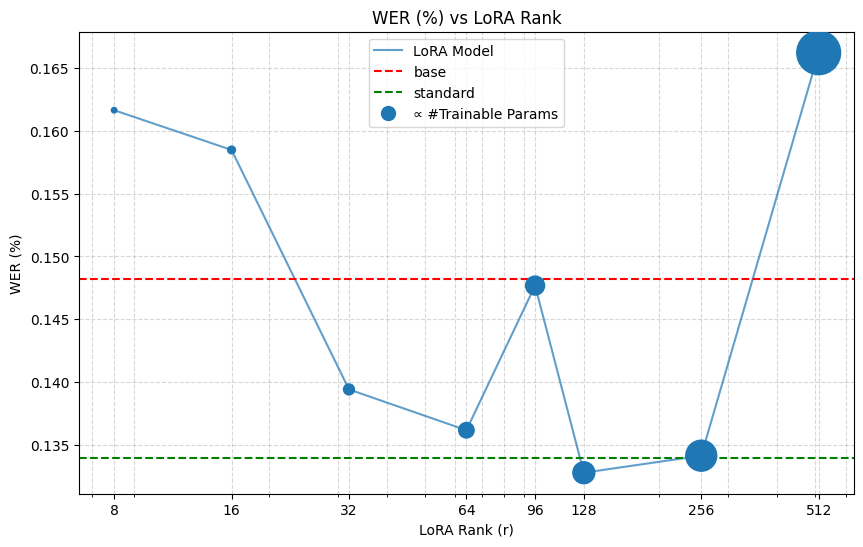

In [ ]:
plot_results(df_total_new)

## Diagnose the rank=96 issue

In [ ]:
import pandas as pd
import evaluate
from tqdm.notebook import tqdm  
import json

In [ ]:
wer_metric = evaluate.load("wer")
tqdm.pandas()

In [ ]:
r_64_preds_path = "/mnt/asr-data-scaling/outputs/gigaspeech/0023/gigaspeech-0023_frac_1.0_subset_0/predictions.json"
r_96_preds_path = "/mnt/asr-data-scaling/outputs/gigaspeech/0027/gigaspeech-0027_frac_1.0_subset_0/predictions.json"

r_64_preds = json.load(open(r_64_preds_path))
r_96_preds = json.load(open(r_96_preds_path))

In [ ]:
df_64.columns

Index(['ID', '64', 'references'], dtype='object')

In [ ]:
df_64 = pd.DataFrame(r_64_preds).reset_index()
df_64.rename(columns={"predictions": "64","index": "ID"}, inplace=True)
df_64["wer_64"] = df_64.progress_apply(lambda x: wer_metric.compute(predictions=[x["64"]], references=[x["references"]]), axis=1)
df_96 = pd.DataFrame(r_96_preds).reset_index()
df_96.rename(columns={"predictions": "96","index": "ID"}, inplace=True)
df_96["wer_96"] = df_96.progress_apply(lambda x: wer_metric.compute(predictions=[x["96"]], references=[x["references"]]), axis=1)
df_total = pd.merge(df_64, df_96,on='ID', how="inner")
df_total.tail()

  0%|          | 0/19898 [00:00<?, ?it/s]

  0%|          | 0/19898 [00:00<?, ?it/s]

,ID,64,references_x,wer_64,96,references_y,wer_96
19893,19893,it was a very difficult experience,it was it was a a very difficult experience,0.333333,it was a very difficult experience,it was it was a a very difficult experience,0.333333
19894,19894,i would say will get attention this time,you know i would say is ah will get attention ...,0.333333,i would say will get attention this time,you know i would say is ah will get attention ...,0.333333
19895,19895,is a very and it just pisses me off that peopl...,is a very and and it just pisses me off that p...,0.317073,is a very and it just pisses me off that peopl...,is a very and and it just pisses me off that p...,0.317073
19896,19896,6 foot one big unit of a defender,6 foot one big unit of a defender,0.000000,6 foot one big unit of a defender,6 foot one big unit of a defender,0.000000
19897,19897,okay what did you love most about the town whe...,okay what did you love most about the town whe...,0.000000,okay what did you love most about the town whe...,okay what did you love most about the town whe...,0.000000


In [ ]:
df_diff = df_total[df_total["wer_96"]!=df_total["wer_64"]].sort_values("wer_96",ascending=False).reset_index(drop=True)
df_diff

,ID,64,references_x,wer_64,96,references_y,wer_96
0,15485,box,books,1.000000,knox knox knox knox knox knox knox knox knox k...,books,222.0
1,1939,shame,hey,1.000000,shame shame shame shame shame shame shame sham...,hey,222.0
2,114,outside outside,outside,1.000000,outside outside outside outside outside outsid...,outside,221.0
3,9671,2,2,0.000000,oopsie oopsie oopsie oopsie oopsie oopsie oops...,2,124.0
4,13537,and i,and i,0.000000,aye aye aye aye aye aye aye aye aye aye aye ay...,and i,111.0
...,...,...,...,...,...,...,...
3557,17422,the far more effective method will always be t...,the far more effective method will always be t...,0.046512,the far more effective method will always be t...,the far more effective method will always be t...,0.0
3558,17413,we got new strategy,me got new strategy,0.250000,me got new strategy,me got new strategy,0.0
3559,17387,and i want you to take a moment to appreciate ...,and i want you to take a moment to appreciate ...,0.047619,and i want you to take a moment to appreciate ...,and i want you to take a moment to appreciate ...,0.0
3560,17376,you really need to find somebody who is willin...,you really need to find somebody who is willin...,0.051282,you really need to find somebody who is willin...,you really need to find somebody who is willin...,0.0


In [ ]:
def count_words(text):
    return len(text.split())

In [ ]:
df_total["count_ref_words"] = df_total["references_x"].apply(lambda x: len(x.split()))
df_total_filtered = df_total[df_total["count_ref_words"] > 5].reset_index(drop=True)
print("mean wer 64:", df_total_filtered["wer_64"].mean())
print("mean wer 96:", df_total_filtered["wer_96"].mean())


mean wer 64: 0.13449995077207272
mean wer 96: 0.1461893194769634


### Experments with multiseed runs

In [9]:
# import pandas as pd
# import matplotlib.pyplot as plt
# from pathlib import Path
# import json

In [10]:
# gigaspeech_002_dir = "../outputs/gigaspeech/002"
# spgispeech_2_002_dir = "../outputs/spgispeech_2/002"
# voxpopuli_002_dir = "../outputs/voxpopuli/002"
# gigaspeech_002_results = list(Path(gigaspeech_002_dir).glob("**/results.json"))
# spgispeech_2_002_results = list(Path(spgispeech_2_002_dir).glob("**/results.json"))
# voxpopuli_002_results = list(Path(voxpopuli_002_dir).glob("**/results.json"))
# seeds = [42,123,1234,12345,123456]
# results={"gigaspeech_m":{},"spgispeech_2":{},"voxpopuli":{}}
# for seed in seeds:
#     for p in gigaspeech_002_results:
#         if f"{seed}_" in str(p):
#             r = json.load(p.open())
#             results["gigaspeech_m"][seed] = r["metrics"]["wer"]
#     for p in spgispeech_2_002_results:
#         if f"{seed}_" in str(p):
#             r = json.load(p.open())
#             results["spgispeech_2"][seed] = r["metrics"]["wer"]
#     for p in voxpopuli_002_results:
#         if f"{seed}_" in str(p):
#             r = json.load(p.open())
#             results["voxpopuli"][seed] = r["metrics"]["voxpopuli-en"]["wer"]

# results    


In [11]:
# df = pd.DataFrame(results).T
# df

In [12]:
# fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(15, 6))
# colors = ['blue', 'red','green']
# for i, (dataset_name, row) in enumerate(df.iterrows()):
#     ax = axes[i]
    
#     # Plot bars
#     row.plot(kind='bar', ax=ax, color=colors[i], edgecolor='black', alpha=0.8, width=0.6)
    
#     # Calculate Variance
#     variance = row.var()
    
#     # Update title with Variance
#     # Using scientific notation or 6 decimal places is usually best for these small values
#     ax.set_title(f"{dataset_name}\nVariance: {variance:.2e}", fontsize=14, fontweight='bold', pad=15)
    
#     ax.set_xlabel('Seed', fontsize=12)
#     ax.set_ylabel('WER', fontsize=12)
#     ax.grid(axis='y', linestyle='--', alpha=0.5)
#     ax.tick_params(axis='x', rotation=0)
    
#     # Add value labels
#     for p in ax.patches:
#         value = p.get_height()
#         if pd.notna(value) and value > 0:
#             ax.annotate(f'{value:.4f}', 
#                         (p.get_x() + p.get_width() / 2., p.get_height()), 
#                         ha='center', va='bottom', 
#                         fontsize=10, fontweight='bold',
#                         xytext=(0, 5), 
#                         textcoords='offset points')
# plt.tight_layout()
# plt.show()

## Multiseeds Analysis

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
import json
import re
from matplotlib.ticker import ScalarFormatter


In [2]:
metadata_lora_r = {
    "000": {"lora_rank": 0,"type": "base"},
    "001": {"lora_rank": 0,"type": "standard"},
    "0020": {"lora_rank": 8,"type": "lora"},
    "0021": {"lora_rank": 16,"type": "lora"},
    "0022": {"lora_rank": 32,"type": "lora"},
    "0023": {"lora_rank": 64,"type": "lora"},
    "0024": {"lora_rank": 128,"type": "lora"},
    "0025": {"lora_rank": 256,"type": "lora"},
    "0026": {"lora_rank": 512,"type": "lora"},
    # "0027": {"lora_rank": 96,"type": "lora"},
}

datasets = ["spgispeech_2", "gigaspeech","voxpopuli"]

exp_ids = list(metadata_lora_r.keys())



dataset_dict = {name: {} for name in datasets}
dataset_dict

{'spgispeech_2': {}, 'gigaspeech': {}, 'voxpopuli': {}}

In [3]:
all_results_paths = list(Path("../outputs").glob("**/results.json"))

In [4]:
filtered_paths = [path for path in all_results_paths if any(dataset in str(path) for dataset in datasets)]

In [5]:
for path in filtered_paths:
    for dataset in datasets:
        if dataset in str(path):
            seed="NA"
            if "seed" in str(path):
                seed = re.search(r'(?<=seed_)[^/_]+', str(path)).group()
            exp_id = next((eid for eid in exp_ids if eid in str(path)), None)

            if exp_id not in ["000", "001"] and seed == "NA":
                continue
            
            r = json.load(path.open())
            if dataset =="voxpopuli":
                wer =  r["metrics"]["voxpopuli-en"]["wer"]
            else:
                wer =  r["metrics"]["wer"]
            
            if exp_id is not None:
                dataset_dict[dataset].update({(exp_id, seed): wer})

df = pd.DataFrame(dataset_dict).reset_index().rename(columns={"level_0": "exp_id", "level_1": "seed"}) 
df            


,exp_id,seed,spgispeech_2,gigaspeech,voxpopuli
0,000,NA,0.115615,0.149531,1.020687
1,0022,123,0.072206,0.142032,0.078005
2,0022,123456,0.071265,0.131587,0.078842
3,0022,12345,0.070489,0.143243,0.078981
4,0022,1234,0.072066,0.156725,0.079144
5,0022,42,0.071233,0.145282,0.079516
6,0023,123,0.068782,0.135098,0.077679
7,0023,123456,0.067725,0.139559,0.079027
8,0023,12345,0.068980,0.139758,0.079562
9,0023,1234,0.070131,0.145599,0.078888


In [6]:
# add metadata to the df
df_metadata = pd.DataFrame(metadata_lora_r).T.reset_index().rename(columns={"index":"exp_id"})
df_total = pd.merge(df_metadata,df,on="exp_id")

# df_total = df_total[df_total['exp_id']!="0024"]
df_total.sort_values(by=['exp_id','lora_rank','seed'], inplace=True)

df_melted = df_total.melt(
    id_vars=['exp_id', 'lora_rank', 'type', 'seed'], # Columns to keep as they are
    value_vars=['spgispeech_2', 'gigaspeech',"voxpopuli"],       # Columns to unpivot
    var_name='dataset',                              # Name for the new "key" column
    value_name='wer'                                 # Name for the new "value" column
)

In [7]:
def aggregate_wer_stats(df):
    # Define Median Absolute Deviation (MAD)
    mad_func = lambda x: (x - x.median()).abs().median()

    # Group by the core identifiers
    # Use tuples in .agg() to extract the 'first' instance of metadata
    stats = df.groupby(['dataset', 'exp_id']).agg(
        lora_rank=('lora_rank', 'first'),
        type=('type', 'first'),
        mean=('wer', 'mean'),
        median=('wer', 'median'),
        std=('wer', 'std'),
        mad=('wer', mad_func)
    ).reset_index()

    # Move metadata columns to the front if desired
    cols = ['exp_id','lora_rank', 'type', 'dataset' , 'mean', 'median', 'std', 'mad']
    return stats[cols]

In [8]:
agg_df = aggregate_wer_stats(df_melted)
agg_df.dropna(subset="mean",inplace=True)
agg_df

,exp_id,lora_rank,type,dataset,mean,median,std,mad
0,000,0,base,gigaspeech,0.149531,0.149531,NaN,0.000000
1,001,0,standard,gigaspeech,0.135231,0.135231,NaN,0.000000
2,0020,8,lora,gigaspeech,0.201482,0.214459,0.023750,0.008624
3,0021,16,lora,gigaspeech,0.164746,0.151800,0.036152,0.008683
4,0022,32,lora,gigaspeech,0.143774,0.143243,0.008970,0.002039
5,0023,64,lora,gigaspeech,0.138069,0.139559,0.005711,0.004462
6,0024,128,lora,gigaspeech,0.138543,0.141829,0.008808,0.004930
7,0025,256,lora,gigaspeech,0.141703,0.142602,0.006462,0.006087
8,0026,512,lora,gigaspeech,0.160983,0.157637,0.006056,0.001593
9,000,0,base,spgispeech_2,0.115615,0.115615,NaN,0.000000


In [9]:
def plot_wer_performance(df, dataset_name, metric_type='mean', color='blue', padding_rate=.15, log_scale=True):
    # 1. Prepare LoRA Data
    df_copy = df.copy()
    metric_cols = ['mean', 'std', 'median', 'mad', 'lora_rank']
    df_copy[metric_cols] = df_copy[metric_cols].apply(pd.to_numeric, errors='coerce')

    subset = df_copy[(df_copy['dataset'] == dataset_name) & (df_copy['lora_rank'] > 0)]
    subset = subset.sort_values('lora_rank').dropna(subset=['lora_rank', 'mean'])
    
    x_labels = subset['lora_rank'].astype(int).astype(str)
    
    if metric_type == 'mean':
        y, err = subset['mean'], subset['std']
        metric_label, err_label = "Mean", "Std Dev"
    else:
        y, err = subset['median'], subset['mad']
        metric_label, err_label = "Median", "MAD"

    plt.figure(figsize=(7, 5))
    
    # 2. Plot LoRA results
    # We assign the line to a variable to manage legend handles if needed
    plt.plot(x_labels, y, marker='o', label=f'WER ({metric_label})', linewidth=2, color=color, zorder=3)
    
    # ADDED LABEL HERE: This makes it eligible for the legend
    plt.fill_between(x_labels, y - err, y + err, color=color, alpha=0.2, zorder=2, 
                     label=f'WER ({err_label})')

    # 3. Baselines
    base_data = df_copy[(df_copy['lora_rank'] == 0) & (df_copy['dataset'] == dataset_name)]
    base_val = base_data[base_data['type'].str.lower() == 'base'][metric_type].mean()
    std_val = base_data[base_data['type'].str.lower() == 'standard'][metric_type].mean()

    all_y_points = y.tolist()

    if pd.notna(base_val):
        plt.axhline(y=base_val, color='black', linestyle='--', alpha=0.7, 
                    label=f'Base ({base_val*100:.2f}%)', zorder=1)
        all_y_points.append(base_val)

    if pd.notna(std_val):
        plt.axhline(y=std_val, color='red', linestyle=':', alpha=0.7, 
                    label=f'Standard-Tuned ({std_val*100:.2f}%)', zorder=1)
        all_y_points.append(std_val)

    # 4. Scale and Smart Limits
    if log_scale:
        plt.yscale('log')
        # Logarithmic padding: Multiply/Divide instead of Add/Subtract
        y_min, y_max = min(all_y_points), max(all_y_points)
        # We use a power-based padding for log scales
        plt.ylim(y_min / (1 + padding_rate), y_max * (1 + padding_rate))
        
        # Fixing the 'get_xaxis' style error by using gca()
        ax = plt.gca()
        ax.yaxis.set_major_formatter(ScalarFormatter())
        ax.yaxis.set_minor_formatter(ScalarFormatter())
    else:
        # Linear padding
        y_min, y_max = min(all_y_points), max(all_y_points)
        padding = (y_max - y_min) * padding_rate if y_max != y_min else 2
        plt.ylim(y_min - padding, y_max + padding)

    # 5. Formatting
    plt.title(f"{dataset_name.title()}: {metric_label} WER for LoRA fine-tuning (Proj_out),\nAggregated over five independent seed initializations.", fontsize=11)
    plt.xlabel("LoRA Rank", fontweight='bold')
    plt.ylabel("WER (%)", fontweight='bold')
    plt.grid(True, which="both", linestyle='--', alpha=0.4)
    
    # The legend will now automatically include the fill_between label
    plt.legend(loc='best', fontsize='small')
    plt.tight_layout()
    plt.show()

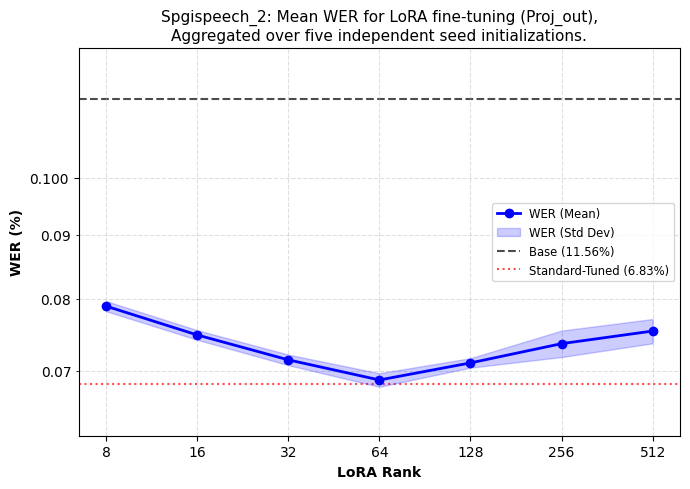

In [10]:
plot_wer_performance(agg_df,dataset_name='spgispeech_2',padding_rate=.10,log_scale=True,metric_type='mean')

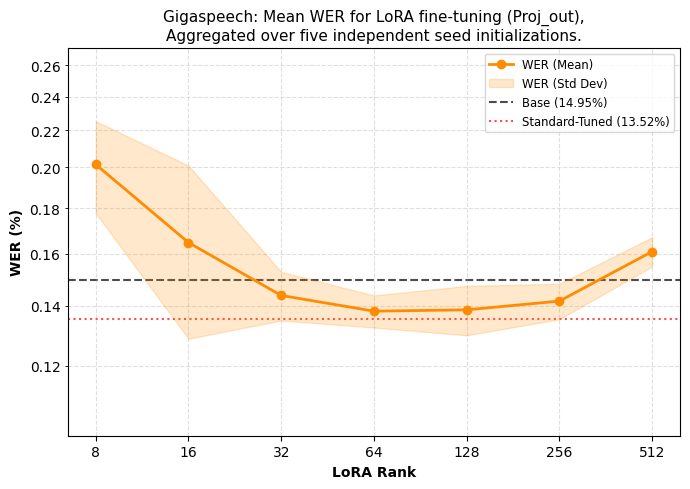

In [10]:
plot_wer_performance(agg_df,dataset_name='gigaspeech',color = 'darkorange',padding_rate=.35,log_scale=True,metric_type='mean')

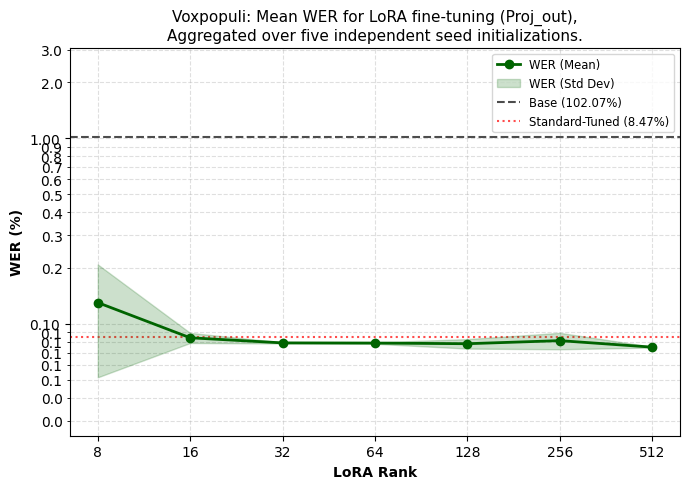

In [11]:
plot_wer_performance(agg_df,dataset_name='voxpopuli',color = 'darkgreen',padding_rate=2,log_scale=True,metric_type='mean')

## Deeper Layers Training Results

In [12]:
import pandas as pd
import matplotlib.pyplot as plt
import json
from pathlib import Path
import seaborn as sns
import numpy as np
import re

In [13]:
spgi_paths = "/mnt/asr-data-scaling/outputs/spgispeech_2"
gigaspeech_paths = "/mnt/asr-data-scaling/outputs/gigaspeech"
voxpopuli_paths = "/mnt/asr-data-scaling/outputs/voxpopuli"

In [14]:
def load_results(dir_to_results):
    all_jsons = list(Path(dir_to_results).glob("**/results.json"))
    # Filtering logic: exclude 002 variants unless they are 0023
    all_jsons_filtered = [p for p in all_jsons if "002" not in str(p) or "0023" in str(p)]
    
    # Group results by run_id to handle multiple seeds
    grouped_data = {}
    
    for p in all_jsons_filtered:
        with open(p, "r") as f:
            data = json.load(f)
        
        if "voxpopuli" in str(p):
            wer =  data["metrics"]["voxpopuli-en"]["wer"]
        else:
            wer = data.get("metrics", {}).get("wer")
            time = data.get("training_time",None)
        
        if wer is None:
            continue
            
        # Determine the grouped run_id
        if "0023" in str(p):
            run_id = "002"
        elif "000" in str(p):
            run_id = "000"
        elif "001" in str(p):
            run_id = "001"
        else:
            try:
                run_id = re.findall(r'\b\d{4,5}\b', str(p))[0]
            except:
                print(p)
            
            
        if run_id not in grouped_data:
            grouped_data[run_id] = {"wers": [], "times": []}
            
        grouped_data[run_id]["wers"].append(wer)
        # if time is not None:
        #     grouped_data[run_id]["times"].append(time)
            
    results = []
    for run_id, values in grouped_data.items():
        # Return the accumulated lists directly without aggregation
        results.append({
            "id": run_id,
            "wer": values["wers"],
            # "training_time": values["times"]
        })
        
    return results

In [15]:
gigaspeech_results = load_results(gigaspeech_paths)
gigaspeech_results

[{'id': '0070', 'wer': [0.10247517025930945]},
 {'id': '0071',
  'wer': [0.09553845048544651,
   0.09495378410450664,
   0.09463915431476357,
   0.09599181467066684,
   0.09595713107179753]},
 {'id': '0041', 'wer': [0.11092558138382605]},
 {'id': '0040', 'wer': [0.10747208589641]},
 {'id': '0060', 'wer': [0.09741879702414721]},
 {'id': '0061', 'wer': [0.09606861406816318]},
 {'id': '000', 'wer': [0.1495309043252925]},
 {'id': '002',
  'wer': [0.13509757239581913,
   0.13955936965036456,
   0.1397575616439035,
   0.14559927065346379,
   0.13033353235112685]},
 {'id': '0080', 'wer': [0.10210356027142393]},
 {'id': '0081',
  'wer': [0.0943170923252628,
   0.09590262827357432,
   0.09463172211500585,
   0.09676476344546871,
   0.09576389387809706]},
 {'id': '0050', 'wer': [0.1097562486219463]},
 {'id': '0051', 'wer': [0.10919387884027955]},
 {'id': '001', 'wer': [0.13523135199145792]}]

In [16]:
gigaspeech_results = load_results(gigaspeech_paths)
gigaspeech_df = pd.DataFrame(gigaspeech_results)
gigaspeech_df

,id,wer
0,0070,[0.10247517025930945]
1,0071,"[0.09553845048544651, 0.09495378410450664, 0.0..."
2,0041,[0.11092558138382605]
3,0040,[0.10747208589641]
4,0060,[0.09741879702414721]
5,0061,[0.09606861406816318]
6,000,[0.1495309043252925]
7,002,"[0.13509757239581913, 0.13955936965036456, 0.1..."
8,0080,[0.10210356027142393]
9,0081,"[0.0943170923252628, 0.09590262827357432, 0.09..."


In [17]:
experiment_types = {
    "000": {"label": "Baseline", "type": "baseline"},
    "001": {"label": "L0", "type": "standard"},
    
    # L0 Experiments (002*)
    "002": {"label": "L0", "type": "lora"},

    # L1 Experiments (003*) - Skipped
    "0030": {"label": "L1", "type": "standard"},
    "0031": {"label": "L1", "type": "lora"},

    # L2 Experiments (004*)
    "0040": {"label": "L2", "type": "standard"},
    "0041": {"label": "L2", "type": "lora"},

    # L3 Experiments (005*)
    "0050": {"label": "L3", "type": "standard"},
    "0051": {"label": "L3", "type": "lora"},

    # L4 Experiments (006*)
    "0060": {"label": "L4", "type": "standard"},
    "0061": {"label": "L4", "type": "lora"},

    # L5 Experiments (007*)
    "0070": {"label": "L5", "type": "standard"},
    "0071": {"label": "L5", "type": "lora"},

    # L6 Experiments (008*)
    "0080": {"label": "L6", "type": "standard"},
    "0081": {"label": "L6", "type": "lora"},
}

In [18]:
experiment_types_df = pd.DataFrame(experiment_types).T.reset_index().rename(columns={"index": "id"})
experiment_types_df

,id,label,type
0,000,Baseline,baseline
1,001,L0,standard
2,002,L0,lora
3,0030,L1,standard
4,0031,L1,lora
5,0040,L2,standard
6,0041,L2,lora
7,0050,L3,standard
8,0051,L3,lora
9,0060,L4,standard


In [19]:
df_gigaspeech_results_total = pd.merge(gigaspeech_df,experiment_types_df,on="id").sort_values(by="id").reset_index(drop=True)  
df_gigaspeech_results_total

,id,wer,label,type
0,000,[0.1495309043252925],Baseline,baseline
1,001,[0.13523135199145792],L0,standard
2,002,"[0.13509757239581913, 0.13955936965036456, 0.1...",L0,lora
3,0040,[0.10747208589641],L2,standard
4,0041,[0.11092558138382605],L2,lora
5,0050,[0.1097562486219463],L3,standard
6,0051,[0.10919387884027955],L3,lora
7,0060,[0.09741879702414721],L4,standard
8,0061,[0.09606861406816318],L4,lora
9,0070,[0.10247517025930945],L5,standard


In [36]:
def plot_wer_comparison(df, title="WER Comparison: Standard vs LoRA Fine-Tuning", log_scale=True, padding_rate=0.05):
    """
    Plots a line chart with fill-between for std.
    Adds ±std labels on top of markers if std is non-zero.
    """
    # 1. Baseline Extraction
    baseline_row = df[df["type"].str.lower() == "baseline"]
    if not baseline_row.empty:
        val = baseline_row["wer"].iloc[0]
        baseline_wer = np.mean(val) if isinstance(val, (list, np.ndarray)) else val
    else:
        baseline_wer = None
        
    # 2. Data Preparation
    plot_df = df[df["type"].str.lower() != "baseline"].copy()
    
    def sort_key(label):
        label_str = str(label)
        if label_str.startswith("L"):
            try: return int(label_str[1:])
            except: return 999
        return 0
        
    unique_labels = sorted(plot_df["label"].unique(), key=sort_key)
    plot_df["label"] = pd.Categorical(plot_df["label"], categories=unique_labels, ordered=True)
    
    exploded_df = plot_df.explode("wer")
    exploded_df["wer"] = pd.to_numeric(exploded_df["wer"])
    
    # 3. Plotting
    plt.figure(figsize=(12, 7))
    sns.set_style("whitegrid")
    palette = {"standard": "#2E86C1", "lora": "#E67E22"}
    
    ax = sns.lineplot(
        data=exploded_df, 
        x="label", 
        y="wer", 
        hue="type", 
        marker="o", 
        palette=palette,
        linewidth=2.5,
        markersize=8,
        errorbar="sd"
    )
    
    # 4. Add ±std labels
    stats = exploded_df.groupby(["label", "type"], observed=True)["wer"].agg(["mean", "std"]).reset_index()
    
    for _, row in stats.iterrows():
        if pd.notnull(row["std"]) and row["std"] > 1e-6:
            # Map categorical label to its numeric index on the X-axis
            x_pos = unique_labels.index(row["label"])
            
            # Label positioning offset (needs to be relative for log scale)
            y_offset = (row["mean"] + row["std"]) * 1.02 if log_scale else (row["mean"] + row["std"] + 0.0005)
            
            plt.text(
                x=x_pos, 
                y=y_offset,
                s=f"±{row['std']:.4f}",
                ha='center', va='bottom', fontsize=9, fontweight='bold',
                bbox=dict(facecolor='white', alpha=0.7, edgecolor='none', pad=1)
            )
    
    if baseline_wer is not None:
        plt.axhline(y=baseline_wer, color="red", linestyle="--", label=f"Baseline: {baseline_wer:.4f}")
    
    # 5. Scale and Limits (Fixed the undefined 'y' and 'padding_rate')
    all_wer_values = exploded_df["wer"].dropna()
    if baseline_wer is not None:
        all_wer_values = pd.concat([all_wer_values, pd.Series([baseline_wer])])
        
    y_min, y_max = all_wer_values.min(), all_wer_values.max()

    if log_scale:
        plt.yscale('log')
        # Log padding: expand by percentage of the magnitude
        plt.ylim(y_min / (1 + padding_rate), y_max * (1 + padding_rate))
    else:
        plt.ylim(y_min - (y_max * padding_rate), y_max + (y_max * padding_rate))
    
    plt.title(title, fontsize=14, fontweight="bold", pad=15)
    plt.ylabel("Word Error Rate (WER)", fontsize=11)
    plt.xlabel("Layers Involved", fontsize=11)
    plt.legend(title="Type", loc="upper center",bbox_to_anchor=(0.5, -0.15), ncol=3)
    plt.tight_layout()
    plt.show()

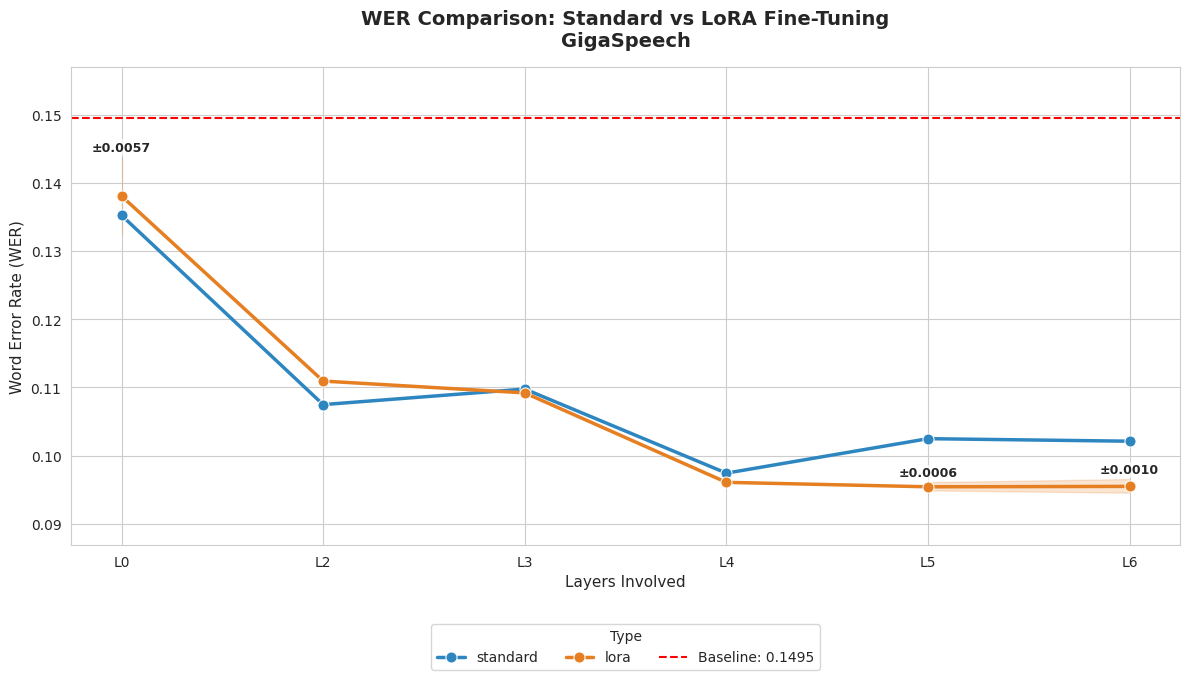

In [37]:
plot_wer_comparison(df_gigaspeech_results_total,
title="WER Comparison: Standard vs LoRA Fine-Tuning\nGigaSpeech",log_scale=False)

In [22]:
spgispeech_results = load_results(spgi_paths)
spgispeech_results

[{'id': '000', 'wer': [0.11561548195786905]},
 {'id': '0070', 'wer': [0.0419323206377262]},
 {'id': '0071', 'wer': [0.04862135291784376]},
 {'id': '0041', 'wer': [0.06716947756044377]},
 {'id': '0040', 'wer': [0.05828067729211338]},
 {'id': '0060', 'wer': [0.04461847306619457]},
 {'id': '0061', 'wer': [0.05201749844577739]},
 {'id': '002',
  'wer': [0.06878245085060307,
   0.06772493856102843,
   0.06898042284824735,
   0.07013051197125275,
   0.06859800931322944]},
 {'id': '0080', 'wer': [0.04173933354649743]},
 {'id': '0081', 'wer': [0.0487203389166659]},
 {'id': '0050', 'wer': [0.05681155415851575]},
 {'id': '0051', 'wer': [0.06934503314606702]},
 {'id': '001', 'wer': [0.06831163596562129]}]

In [38]:
spgispeech_2_df = pd.DataFrame(spgispeech_results)
spgispeech_2_df

,id,wer
0,000,[0.11561548195786905]
1,0070,[0.0419323206377262]
2,0071,[0.04862135291784376]
3,0041,[0.06716947756044377]
4,0040,[0.05828067729211338]
5,0060,[0.04461847306619457]
6,0061,[0.05201749844577739]
7,002,"[0.06878245085060307, 0.06772493856102843, 0.0..."
8,0080,[0.04173933354649743]
9,0081,[0.0487203389166659]


In [24]:
spgispeech_2_df_total = pd.merge(spgispeech_2_df,experiment_types_df,on="id").sort_values(by="id").reset_index(drop=True)  
spgispeech_2_df_total

,id,wer,label,type
0,000,[0.11561548195786905],Baseline,baseline
1,001,[0.06831163596562129],L0,standard
2,002,"[0.06878245085060307, 0.06772493856102843, 0.0...",L0,lora
3,0040,[0.05828067729211338],L2,standard
4,0041,[0.06716947756044377],L2,lora
5,0050,[0.05681155415851575],L3,standard
6,0051,[0.06934503314606702],L3,lora
7,0060,[0.04461847306619457],L4,standard
8,0061,[0.05201749844577739],L4,lora
9,0070,[0.0419323206377262],L5,standard


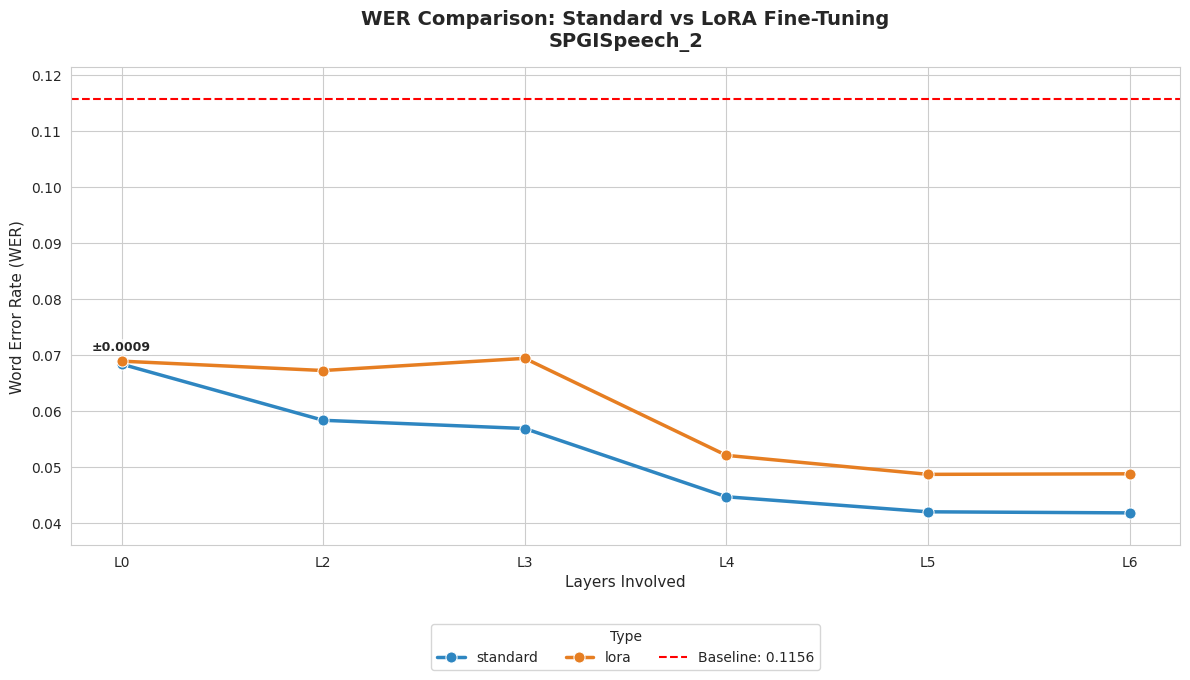

In [39]:
plot_wer_comparison(spgispeech_2_df_total,
title="WER Comparison: Standard vs LoRA Fine-Tuning\nSPGISpeech_2",log_scale=False)

In [26]:
voxpopuli_results = load_results(voxpopuli_paths)
voxpopuli_df = pd.DataFrame(voxpopuli_results)
voxpopuli_df_total = pd.merge(voxpopuli_df,experiment_types_df,on="id").sort_values(by="id").reset_index(drop=True)  

voxpopuli_df_total

,id,wer,label,type
0,000,[1.0206866094879483],Baseline,baseline
1,001,[0.08465239523045813],L0,standard
2,002,"[0.07767938079631825, 0.07902749692025196, 0.0...",L0,lora
3,0050,[0.06821932454733515],L3,standard
4,0051,[0.07300746112544453],L3,lora
5,0060,[0.06261766961857611],L4,standard
6,0061,[0.06615066359854031],L4,lora
7,0070,[0.05875926829835204],L5,standard
8,0071,[0.06389605559816842],L5,lora
9,0080,[0.05903818887571764],L6,standard


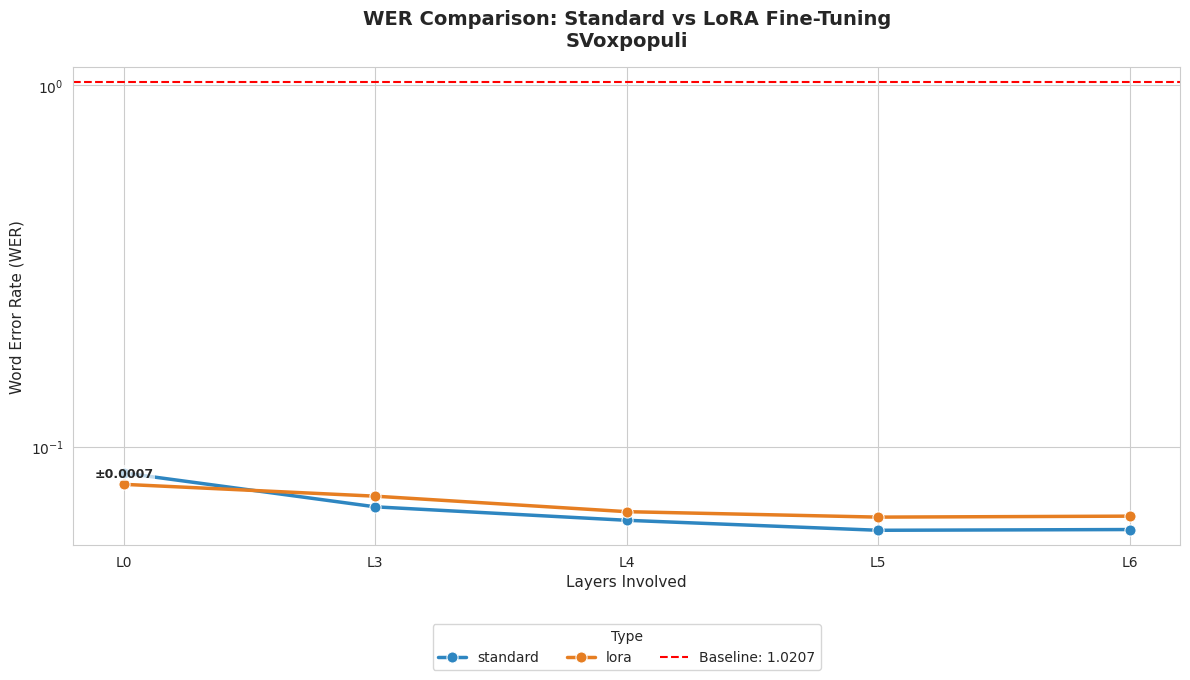

In [42]:
plot_wer_comparison(voxpopuli_df_total,padding_rate=.1,
title="WER Comparison: Standard vs LoRA Fine-Tuning\nSVoxpopuli")

### Optimising 0070 with layer-specific dropout

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import ScalarFormatter
import matplotlib.lines as mlines
from matplotlib.ticker import FormatStrFormatter

import seaborn as sns
from pathlib import Path
import re
import json

In [3]:
# 1. Get all json paths
all_jsons_paths = list(Path("../outputs/gigaspeech/007").glob("**/results.json"))
# 2. Load the jsons into memory
all_jsons = [json.load(open(j)) for j in all_jsons_paths]
# 3. Update each dictionary with the new key (using a fast loop instead of list comprehension)
for item in all_jsons:
    item['exp_id'] = item['model_path'].split("/")[-2]
    try:
        item["wer"] = item["metrics"]["speechcolab-gigaspeech-m"]["wer"]
    except KeyError:
        item["wer"] = item["metrics"]["wer"]
df_007 = pd.DataFrame(all_jsons)
df_007 = df_007.groupby("exp_id").agg({"wer": "mean"}).reset_index()
df_007


,exp_id,wer
0,0070,0.102475
1,00701-d,0.100466
2,00702-d,0.100600
3,00703-d,0.100134
4,00704-d,0.099366
5,00705-d,0.103194
6,00706-d,0.100424
7,00707-d,0.099205
8,00708-d,0.100149
9,0071,0.095416


In [4]:
hyperparameters_list = [
    {"exp_id": "0070",   "dropout": 0.0, "attention_dropout": 0.0, "activation_dropout": 0.0, "weight_decay": 0.0,"type":"base"},
    {"exp_id": "00701-d", "dropout": 0.1, "attention_dropout": 0.0, "activation_dropout": 0.0, "weight_decay": 0.1,"type":"base"},
    {"exp_id": "00702-d", "dropout": 0.5, "attention_dropout": 0.0, "activation_dropout": 0.0, "weight_decay": 0.1,"type":"base"},
    {"exp_id": "00703-d", "dropout": 0.1, "attention_dropout": 0.1, "activation_dropout": 0.1, "weight_decay": 0.1,"type":"base"},
    {"exp_id": "00704-d", "dropout": 0.2, "attention_dropout": 0.2, "activation_dropout": 0.2, "weight_decay": 0.1,"type":"base"},
    {"exp_id": "00705-d", "dropout": 0.2, "attention_dropout": 0.5, "activation_dropout": 0.5, "weight_decay": 0.1,"type":"base"},
    {"exp_id": "00706-d", "dropout": 0.3, "attention_dropout": 0.3, "activation_dropout": 0.3, "weight_decay": 0.1,"type":"base"},
    {"exp_id": "00707-d", "dropout": 0.15, "attention_dropout": 0.15, "activation_dropout": 0.15, "weight_decay": 0.1,"type":"base"},
    {"exp_id": "00708-d", "dropout": 0.25, "attention_dropout": 0.25, "activation_dropout": 0.25, "weight_decay": 0.1,"type":"base"},
    {"exp_id": "0071", "dropout": 0.0, "attention_dropout": 0.0, "activation_dropout": 0.0, "weight_decay": 0.0,"type":"lora"},
]
df_hyp = pd.DataFrame(hyperparameters_list)
df_hyp

,exp_id,dropout,attention_dropout,activation_dropout,weight_decay,type
0,0070,0.00,0.00,0.00,0.0,base
1,00701-d,0.10,0.00,0.00,0.1,base
2,00702-d,0.50,0.00,0.00,0.1,base
3,00703-d,0.10,0.10,0.10,0.1,base
4,00704-d,0.20,0.20,0.20,0.1,base
5,00705-d,0.20,0.50,0.50,0.1,base
6,00706-d,0.30,0.30,0.30,0.1,base
7,00707-d,0.15,0.15,0.15,0.1,base
8,00708-d,0.25,0.25,0.25,0.1,base
9,0071,0.00,0.00,0.00,0.0,lora


In [5]:
df_all = pd.merge(df_007,df_hyp,on="exp_id")
df_all

,exp_id,wer,dropout,attention_dropout,activation_dropout,weight_decay,type
0,0070,0.102475,0.00,0.00,0.00,0.0,base
1,00701-d,0.100466,0.10,0.00,0.00,0.1,base
2,00702-d,0.100600,0.50,0.00,0.00,0.1,base
3,00703-d,0.100134,0.10,0.10,0.10,0.1,base
4,00704-d,0.099366,0.20,0.20,0.20,0.1,base
5,00705-d,0.103194,0.20,0.50,0.50,0.1,base
6,00706-d,0.100424,0.30,0.30,0.30,0.1,base
7,00707-d,0.099205,0.15,0.15,0.15,0.1,base
8,00708-d,0.100149,0.25,0.25,0.25,0.1,base
9,0071,0.095416,0.00,0.00,0.00,0.0,lora


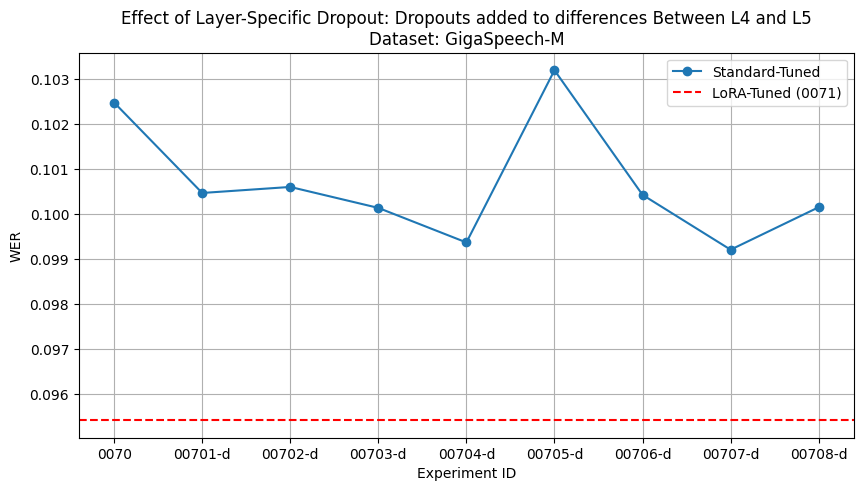

In [8]:
fig,ax = plt.subplots(1,1,figsize=(10,5))
x = df_all[df_all["type"]=="base"]["exp_id"]
y = df_all[df_all["type"]=="base"]["wer"]
ax.plot(x,y,marker="o")
lora_wer = df_all[df_all["type"]=="lora"]['wer'].values[0]
lora_exp_id = df_all[df_all["type"]=="lora"]['exp_id'].values[0]
# 2. Draw the horizontal line
ax.axhline(lora_wer, color="r", linestyle="--")
# # 3. Add the exp_id as text at the y-coordinate of the line
# ax.text(7.5, lora_wer+.0002, f' {lora_exp_id}', color="red", va='bottom', ha='left')
ax.set_title("Effect of Layer-Specific Dropout: Dropouts added to differences Between L4 and L5\nDataset: GigaSpeech-M")
ax.set_xlabel("Experiment ID")
ax.set_ylabel("WER")
plt.legend(["Standard-Tuned","LoRA-Tuned (0071)"])
ax.grid(True)
plt.show()


In [53]:
df_all[df_all["type"]=="lora"]['wer'].values[0]

0.09541606692943622

## Data Scaling Results 

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import json
from pathlib import Path
import re

In [2]:
results_dir = "/mnt/asr-data-scaling/outputs/spgispeech_2/002/0023"
all_res_paths = list(Path(results_dir).glob("**/results.json"))
baseline_res_path = Path("/mnt/asr-data-scaling/outputs/spgispeech_2/000/results.json")
all_res_paths = all_res_paths + [baseline_res_path]
all_res_paths

[PosixPath('/mnt/asr-data-scaling/outputs/spgispeech_2/002/0023/seed_123_frac_1.0_subset_0/results.json'),
 PosixPath('/mnt/asr-data-scaling/outputs/spgispeech_2/002/0023/seed_123456_frac_1.0_subset_0/results.json'),
 PosixPath('/mnt/asr-data-scaling/outputs/spgispeech_2/002/0023/seed_12345_frac_1.0_subset_0/results.json'),
 PosixPath('/mnt/asr-data-scaling/outputs/spgispeech_2/002/0023/seed_1234_frac_1.0_subset_0/results.json'),
 PosixPath('/mnt/asr-data-scaling/outputs/spgispeech_2/002/0023/seed_42_frac_1.0_subset_0/results.json'),
 PosixPath('/mnt/asr-data-scaling/outputs/spgispeech_2/002/0023/data_scaling/data_scaling_frac_0.05_subset_1/results.json'),
 PosixPath('/mnt/asr-data-scaling/outputs/spgispeech_2/002/0023/data_scaling/data_scaling_frac_0.05_subset_4/results.json'),
 PosixPath('/mnt/asr-data-scaling/outputs/spgispeech_2/002/0023/data_scaling/data_scaling_frac_0.05_subset_3/results.json'),
 PosixPath('/mnt/asr-data-scaling/outputs/spgispeech_2/002/0023/data_scaling/data_sca

In [44]:
def parse_results_file(file_path, dataset_name):
    """
    Parses a results.json file to extract the experiment ID, data fraction, and WER.
    
    Args:
        file_path (str or Path): The path to the results.json file.
        dataset_name (str): The dataset name, used for looking up nested WER and path splitting.
        
    Returns:
        dict: A dictionary containing 'experiment_id', 'fraction', and 'wer'.
    """
    file_path_obj = Path(file_path)
    path_str = str(file_path_obj)
    
    # 1. Extract Fraction from the parent directory's name
    try:
        # Example parent name: 'data_scaling_frac_0.05_subset_4'
        fraction_str = file_path_obj.parent.name.split('frac_')[1].split('_')[0]
        fraction = float(fraction_str)
    except IndexError:
        fraction = None
        
    # 2. Extract Experiment ID using a flexible regular expression
    # This safely catches both single IDs ("0023") or nested IDs ("002/0023") matching just directories with digits
    exp_id_match = re.search(rf"{dataset_name}/((?:\d+/)*\d+)", path_str)
    experiment_id = exp_id_match.group(1) if exp_id_match else None
        
    # 3. Read the JSON to extract WER
    with open(file_path_obj, 'r') as f:
        data = json.load(f)
        
    metrics = data.get("metrics", {})
    wer = None
    
    # Handle Case 1: 'wer' is directly inside metrics
    if "wer" in metrics:
        wer = metrics["wer"]
    # Handle Case 2: 'wer' is nested inside the dataset name dictionary
    elif dataset_name in metrics and "wer" in metrics[dataset_name]:
        wer = metrics[dataset_name]["wer"]
    # Fallback Case: Search for any nested dictionary that has 'wer' just in case
    else:
        for key, value in metrics.items():
            if isinstance(value, dict) and "wer" in value:
                wer = value["wer"]
                break

    if "half" in str(file_path):
        steps= "50% steps"
    else:
        steps = "100% steps"
    if experiment_id =="000":
        steps = None
    

    return {
        "experiment_id": experiment_id,
        "fraction": fraction,
        "wer": wer,
        "steps":steps
    }

In [58]:
all_results = []
dataset_name = 'spgispeech_2'
for p in all_res_paths:
    res = parse_results_file(p,dataset_name)
    all_results.append(res) 

df = pd.DataFrame(all_results)
df

,experiment_id,fraction,wer,steps
0,002/0023,1.00,0.068782,100% steps
1,002/0023,1.00,0.067725,100% steps
2,002/0023,1.00,0.068980,100% steps
3,002/0023,1.00,0.070131,100% steps
4,002/0023,1.00,0.068598,100% steps
5,002/0023,0.05,0.077861,100% steps
6,002/0023,0.05,0.078886,100% steps
7,002/0023,0.05,0.078908,100% steps
8,002/0023,0.05,0.078037,100% steps
9,002/0023,0.05,0.079333,100% steps


In [71]:
def plot_wer_results(df):
    """
    Plots a line graph of WER with combined experiment_id and repetition on the X-axis 
    for scaled data (fractions < 1.0).
    Adds two horizontal lines:
    1: The baseline '000' run.
    2: The mean WER of the fraction 1.0 runs.
    """
    plot_df = df.copy()
    
    # 1. Identify and extract the vanilla baseline (experiment_id == '000')
    baseline_rows = plot_df[plot_df['experiment_id'] == '000']
    vanilla_wer = None
    if not baseline_rows.empty:
        vanilla_wer = baseline_rows['wer'].iloc[0]
        
    # 2. Identify and calculate the mean for the Fraction 1.0 baseline
    # Ensure fraction is treated as a numeric value for checking 1.0
    plot_df['fraction_num'] = pd.to_numeric(plot_df['fraction'], errors='coerce')
    frac_1_rows = plot_df[plot_df['fraction_num'] == 1.0]
    
    frac_1_mean_wer = None
    if not frac_1_rows.empty:
        frac_1_mean_wer = frac_1_rows['wer'].mean()
        
    # 3. Remove the vanilla baseline and the 1.0 fraction runs from the line plotting dataframe
    plot_df = plot_df[(plot_df['experiment_id'] != '000') & (plot_df['fraction_num'] != 1.0)].copy()
    
    # 4. Add a 'repetition' column for the remaining data
    plot_df['repetition'] = plot_df.groupby(['experiment_id','steps', 'fraction']).cumcount() + 1
    
    # 5. Combine Experiment ID and Repetition for the X-axis label
    # BUG FIX 1: Added `plot_df['experiment_id']` mapping to the string layout.
    plot_df['x_axis_label'] = " (Rep " + plot_df['repetition'].astype(str) + ")"
    
    # Ensure fraction is a string for categorical legend coloring
    plot_df['fraction'] = plot_df['fraction'].astype(str)
    
    # 6. Create the plot
    plt.figure(figsize=(10, 6))
    
    # Draw the main line(s) for the scaled fractions (e.g. 0.05)
    if not plot_df.empty:
        sns.lineplot(
            data=plot_df[plot_df["steps"].isin(["100% steps", "50% steps"])], 
            x='x_axis_label', 
            y='wer', 
            # BUG FIX 2: Used `steps` for `hue` effectively to utilize your defined palette safely.
            hue='steps', 
            # style='fraction',
            marker='o',
            palette={
                "100% steps": "blue",
                "50% steps": "red"
            },
            linewidth=2,
            markersize=8,

        )

    # 7. Add the Horizontal Line for the Vanilla Baseline (000)
    if vanilla_wer is not None:
        plt.axhline(
            y=vanilla_wer, 
            color='red', 
            linestyle='--', 
            linewidth=2, 
            label=f"Vanilla (000) (WER: {vanilla_wer:.4f})"
        )
        
    # 8. Add the Horizontal Line for the Mean of Fraction 1.0
    if frac_1_mean_wer is not None:
        plt.axhline(
            y=frac_1_mean_wer, 
            color='green', 
            linestyle='-.', 
            linewidth=2, 
            label=f"Fraction 1.0 Mean (WER: {frac_1_mean_wer:.4f})"
        )

    frac_05_rows = plot_df[plot_df['fraction_num'] == 0.05]
    
    if not frac_05_rows.empty:
        mean_wer_by_steps=frac_05_rows.groupby('steps')['wer'].mean()

    text_lines = ["Mean WER (Fraction 0.05):"]
    for step_name, mean_val in mean_wer_by_steps.items():
        text_lines.append(f"  {step_name}: {mean_val:.4f}")
        
    text_box_str = "\n".join(text_lines)
    
    # Add the text box to the top-left of the plot
    plt.text(
        0.02, 0.76,  # X, Y coordinates
        text_box_str,
        transform=plt.gca().transAxes,
        fontsize=11,
        verticalalignment='top',
        bbox=dict(boxstyle='round,pad=0.5', facecolor='white', edgecolor='gray', alpha=0.8)
    )
        
    # 9. Formatting the plot
    # BUG FIX 3: Fixed typo "Fine-tuining" to "Fine-tuning"
    plt.title('WER by Experiment Repetition and Data Fraction\nFine-tuning L0 (Proj_out layer)', fontsize=14)
    plt.xlabel('Experiment ID and Repetition', fontsize=12)
    plt.ylabel('Word Error Rate (WER)', fontsize=12)
    
    # Uncommented and positioned properly 
    plt.xticks(rotation=0, ha='right')
    plt.grid(True, linestyle='--', alpha=0.6)
    
    # Combine legends to show both the horizontal lines and the fraction categories
    plt.legend(
        title='Baselines & Data Fractions',
        loc='upper center',
        bbox_to_anchor=(0.5, -0.25), # Adjusted slightly lower because of the x-tick rotation
        ncol=2
    )
    plt.tight_layout()
    
    plt.show()


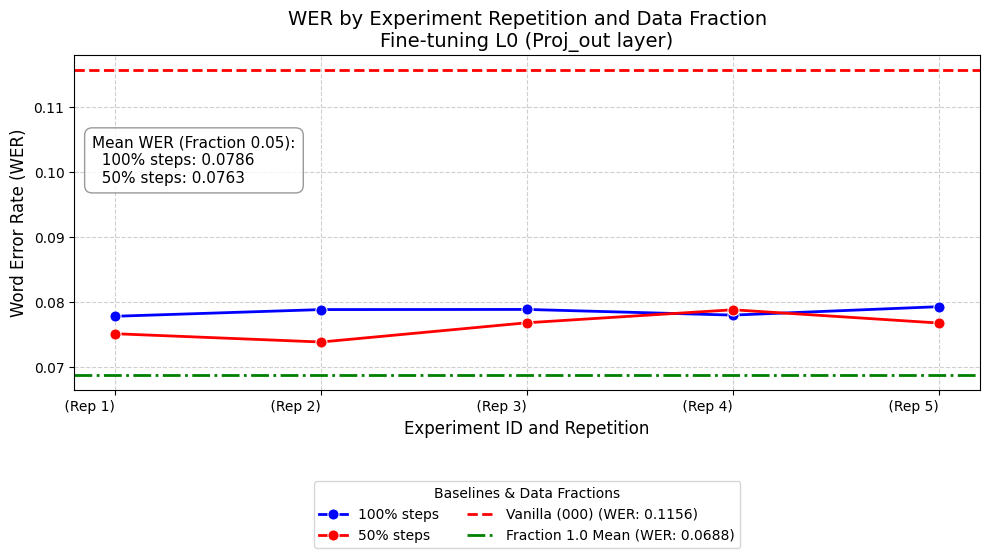

In [72]:
plot_wer_results(df)